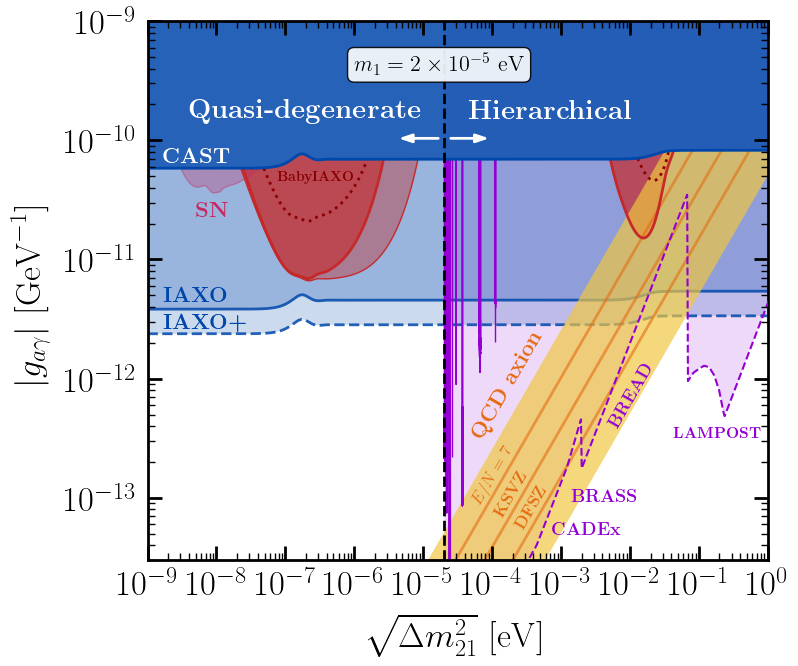

In [3]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib.ticker import LogLocator, FixedLocator, LogFormatterMathtext, NullFormatter
from palettable.colorbrewer.sequential import YlOrRd_5
from palettable.cartocolors.qualitative import Bold_10
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":25,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":2,
   "lines.linewidth":2,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":2,
   "xtick.minor.width":1,
   "ytick.major.width":2,
   "ytick.minor.width":1,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[8,7],
   "savefig.dpi":300,
   "savefig.transparent":True
})

gs = gridspec.GridSpec(1,1,wspace=0.0)
fig = plt.figure()
ax = fig.add_subplot(gs[0])
ax.set_xlim(left=1e-9,right=1e0)
ax.set_ylim(bottom=3e-14,top=1e-9)
ax.xaxis.set_zorder(1000)
ax.yaxis.set_zorder(1000)
ax.tick_params(axis='x',pad=8)
ax.tick_params(axis='y',pad=8) 
x_min,x_max = ax.get_xlim()
y_min,y_max = ax.get_ylim()
ax.set_xlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$",labelpad=10)
ax.set_ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$",labelpad=10)

reds = YlOrRd_5.mpl_colors
bolds = Bold_10.mpl_colors

# Exclusion limit CAST @95 CL
CAST = np.loadtxt(os.path.join("input_data","CAST_exclusion.dat"))
x_CAST = CAST[:,0]
g_excl_CAST = CAST[:,1]
plt.loglog(x_CAST,g_excl_CAST,color="#0047AB",zorder=1)
ax.fill_between(x_CAST,g_excl_CAST,ax.get_ylim()[1],facecolor="#0047AB",zorder=0.5,alpha=0.85)
ax.text(1.7e-9,6.5e-11,r'{\bf CAST}',fontsize=16,color='w',zorder=1000)

# Exclusion limit IAXO @95 CL
IAXO = np.loadtxt(os.path.join("input_data","IAXO_projection.dat"))
x_IAXO = IAXO[:,0]
g_excl_IAXO = IAXO[:,1]
plt.loglog(x_IAXO,g_excl_IAXO,color="#0047AB",zorder=0.7,alpha=0.85)
ax.fill_between(x_IAXO,g_excl_IAXO,g_excl_CAST,facecolor="#0047AB",zorder=0.05,alpha=0.4)
ax.text(1.7e-9,4.5e-12,r'{\bf IAXO}',fontsize=16,color="#0047AB",zorder=1000)

# Exclusion limit IAXOplus @95 CL
IAXOplus = np.loadtxt(os.path.join("input_data","IAXOplus_projection.dat"))
x_IAXOplus = IAXOplus[:,0]
g_excl_IAXOplus = IAXOplus[:,1]
plt.loglog(x_IAXOplus,g_excl_IAXOplus,color="#0047AB",ls='--',zorder=0.7,alpha=0.85)
ax.fill_between(x_IAXOplus,g_excl_IAXOplus,g_excl_IAXO,facecolor="#0047AB",zorder=0.05,alpha=0.2)
ax.text(1.7e-9,2.65e-12,r'{\bf IAXO+}',fontsize=16,color="#0047AB",zorder=1000)

# Discovery: quasi-degenerate (w_res = 10 eV)
IAXO_10eV = np.loadtxt(os.path.join("results_data","Quasi-degenerate","Quasideg_IAXO_disc_10eV.dat"))
x_IAXO_10eV = IAXO_10eV[:,0]
g_disc_IAXO_10eV = IAXO_10eV[:,1]
logg_CAST_on_IAXO_10eV = np.interp(
    np.log10(x_IAXO_10eV),
    np.log10(x_CAST),
    np.log10(g_excl_CAST)
)
g_CAST_on_IAXO_10eV = 10**logg_CAST_on_IAXO_10eV
mask_10eV = g_disc_IAXO_10eV <= g_CAST_on_IAXO_10eV
plt.loglog(
    x_IAXO_10eV[mask_10eV],
    g_disc_IAXO_10eV[mask_10eV],
    color='#C62828',
    lw=1,
    label=r'$\omega_\mathrm{res} = 10\ \mathrm{eV}$',
    zorder=0.9,
    alpha=0.99
)
ax.fill_between(
    x_IAXO_10eV,
    g_disc_IAXO_10eV,
    g_CAST_on_IAXO_10eV,
    where=mask_10eV,
    facecolor='#C62828',
    interpolate=True,
    alpha=0.4,
    zorder=0.1
)

# Discovery: quasi-degenerate (w_res = 100 eV)
IAXO_100eV = np.loadtxt(os.path.join("results_data","Quasi-degenerate","Quasideg_IAXO_disc_100eV.dat"))
x_IAXO_100eV = IAXO_100eV[:,0]
g_disc_IAXO_100eV = IAXO_100eV[:,1]

logg_CAST_on_IAXO_100eV = np.interp(
    np.log10(x_IAXO_100eV),
    np.log10(x_CAST),
    np.log10(g_excl_CAST)
)
g_CAST_on_IAXO_100eV = 10**logg_CAST_on_IAXO_100eV
mask_100eV = g_disc_IAXO_100eV <= g_CAST_on_IAXO_100eV
plt.loglog(
    x_IAXO_100eV[mask_100eV],
    g_disc_IAXO_100eV[mask_100eV],
    color='#C62828',
    lw=2,
    label=r'$\omega_\mathrm{res} = 100\ \mathrm{eV}$',
    zorder=0.9,
    alpha=0.99
)
ax.fill_between(
    x_IAXO_100eV,
    g_disc_IAXO_100eV,
    g_CAST_on_IAXO_100eV,
    where=mask_100eV,
    facecolor='#C62828',
    interpolate=True,
    alpha=0.6,
    zorder=0.1
)

BabyIAXO_100eV = np.loadtxt(os.path.join("results_data","Quasi-degenerate","Quasideg_BabyIAXO_disc_100eV.dat"))
x_BabyIAXO_100eV = BabyIAXO_100eV[:,0]
g_disc_BabyIAXO_100eV = BabyIAXO_100eV[:,1]

logg_CAST_on_BabyIAXO_100eV = np.interp(
    np.log10(x_BabyIAXO_100eV),
    np.log10(x_CAST),
    np.log10(g_excl_CAST)
)
g_CAST_on_BabyIAXO_100eV = 10**logg_CAST_on_BabyIAXO_100eV
mask_100eV = g_disc_BabyIAXO_100eV <= g_CAST_on_BabyIAXO_100eV
plt.loglog(
    x_BabyIAXO_100eV[mask_100eV],
    g_disc_BabyIAXO_100eV[mask_100eV],
    color='darkred',
    lw=2,
    label=r'$\omega_\mathrm{res} = 100\ \mathrm{eV}$',
    zorder=0.9,
    alpha=1.0,
    ls='dotted'
)
ax.text(7.5e-8,4.6e-11,r'{\bf BabyIAXO}',fontsize=10,color="darkred",zorder=1000)

# Discovery limit: hierarchical (w_res = 100 eV)
IAXO_hier_100eV = np.loadtxt(os.path.join("results_data","Hierarchical","Hierarchical_IAXO_disc_100eV.dat"))
x_IAXO_hier_100eV = IAXO_hier_100eV[:,0]
g_disc_IAXO_hier_100eV = IAXO_hier_100eV[:,1]
logg_CAST_on_IAXO_hier_100eV = np.interp(
    np.log10(x_IAXO_hier_100eV),
    np.log10(x_CAST),
    np.log10(g_excl_CAST)
)
g_CAST_on_IAXO_hier_100eV = 10**logg_CAST_on_IAXO_hier_100eV
mask_hier_100eV = g_disc_IAXO_hier_100eV <= g_CAST_on_IAXO_hier_100eV
plt.loglog(
    x_IAXO_hier_100eV[mask_hier_100eV],
    g_disc_IAXO_hier_100eV[mask_hier_100eV],
    color='#C62828',
    lw=2,
    label=r'$\omega_\mathrm{res} = 100\ \mathrm{eV}$',
    zorder=0.9,
    alpha=0.99
)
ax.fill_between(
    x_IAXO_hier_100eV,
    g_disc_IAXO_hier_100eV,
    g_CAST_on_IAXO_hier_100eV,
    where=mask_hier_100eV,
    facecolor='#C62828',
    interpolate=True,
    alpha=0.7,
    zorder=0.1
)

BabyIAXO_hier_100eV = np.loadtxt(os.path.join("results_data","Hierarchical","Hierarchical_BabyIAXO_disc_100eV.dat"))
x_BabyIAXO_hier_100eV = BabyIAXO_hier_100eV[:,0]
g_disc_BabyIAXO_hier_100eV = BabyIAXO_hier_100eV[:,1]
logg_CAST_on_BabyIAXO_hier_100eV = np.interp(
    np.log10(x_BabyIAXO_hier_100eV),
    np.log10(x_CAST),
    np.log10(g_excl_CAST)
)
g_CAST_on_BabyIAXO_hier_100eV = 10**logg_CAST_on_BabyIAXO_hier_100eV
mask_hier_100eV = g_disc_BabyIAXO_hier_100eV <= g_CAST_on_BabyIAXO_hier_100eV
plt.loglog(
    x_BabyIAXO_hier_100eV[mask_hier_100eV],
    g_disc_BabyIAXO_hier_100eV[mask_hier_100eV],
    color='darkred',
    lw=2,
    label=r'$\omega_\mathrm{res} = 100\ \mathrm{eV}$',
    zorder=0.9,
    alpha=1.0,
    ls='dotted'
)

# Discovery limit: SN (w_res = 1 MeV)
IAXO_1MeV = np.loadtxt(os.path.join("results_data","Quasi-degenerate","SN_Quasideg_IAXO_disc_1MeV.dat"))
x_IAXO_1MeV = IAXO_1MeV[:,0]
g_disc_IAXO_1MeV = IAXO_1MeV[:,1]
logg_CAST_on_IAXO_1MeV = np.interp(
    np.log10(x_IAXO_1MeV),
    np.log10(x_CAST),
    np.log10(g_excl_CAST)
)
g_CAST_on_IAXO_1MeV = 10**logg_CAST_on_IAXO_1MeV
mask_1MeV = g_disc_IAXO_1MeV <= g_CAST_on_IAXO_1MeV
plt.loglog(
    x_IAXO_1MeV[mask_1MeV],
    g_disc_IAXO_1MeV[mask_1MeV],
    color="#C62862",
    lw=1,
    label=r'$\omega_\mathrm{res} = 1\ \mathrm{MeV}$',
    zorder=0.9,
    alpha=0.4
)
ax.fill_between(
    x_IAXO_1MeV,
    g_disc_IAXO_1MeV,
    g_CAST_on_IAXO_1MeV,
    where=mask_1MeV,
    facecolor="#C62862",
    interpolate=True,
    alpha=0.3,
    zorder=0.1
)
ax.text(5e-9,2.3e-11,r'{\bf SN}',fontsize=16,color="#C62862",zorder=1000)

# QCD axion band
g_min,g_max = y_min,y_max
m_min,m_max = x_min,x_max
x_all = np.logspace(np.log10(m_min),np.log10(m_max),1000)
def g_ag(C_ag, m_a):
    return 2e-10 * C_ag * m_a
g_KSVZ = g_ag(1.92,x_all)
g_DFSZ = g_ag(0.75,x_all)
g_upper = g_ag(44/3 - 1.92,x_all)
g_lower = g_ag(1.92 - 5/3,x_all)
g_lim = g_ag(7 - 1.92,x_all)
g_cut = g_excl_CAST[-1]
colQCD = "#F0C74086"
col_line = plt.get_cmap("YlOrBr")(0.65)
mask_KSVZ = g_KSVZ <= g_cut
mask_DFSZ = g_DFSZ <= g_cut
mask_lim = g_lim <= g_cut
ax.plot(x_all[mask_KSVZ],g_KSVZ[mask_KSVZ],lw=2,color=col_line,alpha=0.58,zorder=0.82)
ax.plot(x_all[mask_DFSZ],g_DFSZ[mask_DFSZ],lw=2,color=col_line,alpha=0.58, zorder=0.82)
ax.plot(x_all[mask_lim],g_lim[mask_lim],lw=2,color=col_line,alpha=0.58, zorder=0.82)
mask_band = g_lower <= g_cut
g_upper_eff = np.minimum(g_upper,g_cut)
ax.fill_between(x_all,g_lower,g_upper_eff,where=mask_band,facecolor=colQCD,alpha=0.69,zorder=0.8)
ax.text(4.7e-5,3.2e-13,r'{\bf QCD\ axion}',fontsize=16,color=col_line,zorder=0.82,rotation=60)
ax.text(1e-4,7e-14,r'{\bf KSVZ}',fontsize=12,color=col_line,zorder=0.82,rotation=60)
ax.text(2e-4,5.5e-14,r'{\bf DFSZ}',fontsize=12,color=col_line,zorder=0.82,rotation=60)
ax.text(4.6e-5,9.1e-14,r'{\bf $E/N = 7$}',fontsize=12,color=col_line,zorder=0.82,rotation=60)

# Division: quasi-degenerate vs. hierarchical
m1_value = 2e-5 # [eV]
ax.vlines(m1_value,y_min,y_max,ls='--',lw=2,color='k')
ax.text(0.1/2*m1_value,3.8e-10,r'$m_1 = 2\times 10^{-5}\ \mathrm{eV}$',bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.9),fontsize=16)
lowerfactor=1.3
ax.text(1.5e-5+1.6*m1_value,2e-10/lowerfactor,r'{\bf Hierarchical}',fontsize=20,color='w')
ax.text(0.04e-7,2e-10/lowerfactor,r'{\bf Quasi-degenerate}',fontsize=20,color='w')
ax.annotate('',xy=(m1_value/5,1.35e-10/lowerfactor),xytext=(m1_value/1.1,1.35e-10/lowerfactor),
            arrowprops=dict(arrowstyle='-|>,head_length=0.3,head_width=0.1',color='w',lw=2))
ax.annotate('',xy=(m1_value*5,1.35e-10/lowerfactor),xytext=(1.15*m1_value,1.35e-10/lowerfactor),
            arrowprops=dict(arrowstyle='-|>,head_length=0.3,head_width=0.1',color='w',lw=2))

# Haloscopes bounds
# ADMX
ADMX=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","ADMX_Sidecar_AC.txt"))
m_ADMX=ADMX[:,0]
g_ADMX=ADMX[:,1]
mask_bottom=g_ADMX<1e-2
m_bottom=m_ADMX[mask_bottom]
g_bottom=g_ADMX[mask_bottom]
m_unique=np.unique(m_bottom)
g_lower=np.array([g_bottom[m_bottom==m].min() for m in m_unique])
logg_CAST_on_ADMX=np.interp(np.log10(m_unique),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_ADMX=10**logg_CAST_on_ADMX
mask_ADMX=(g_lower<=g_CAST_on_ADMX)&(m_unique>=2e-5)
ax.fill_between(m_unique,g_lower,g_CAST_on_ADMX,where=mask_ADMX,color='darkviolet',interpolate=True,zorder=0.9)

ADMX=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","ADMX_Sidecar.txt"))
m_ADMX=ADMX[:,0]
g_ADMX=ADMX[:,1]
idx=np.where(g_ADMX>=1e-2)[0]
chunks=np.split(np.arange(len(g_ADMX)),idx)
for ch in chunks:
    m=m_ADMX[ch]
    g=g_ADMX[ch]
    mask=g<1e-2
    if np.sum(mask)==0: continue
    m=m[mask]
    g=g[mask]
    logg_CAST=np.interp(np.log10(m),np.log10(x_CAST),np.log10(g_excl_CAST))
    g_CAST=10**logg_CAST
    mask_final=(g<=g_CAST)&(m>=2e-5)
    ax.fill_between(m,g,g_CAST,where=mask_final,color='darkviolet',interpolate=True,zorder=0.9)

# HAYSTAC
HAYSTAC = np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","HAYSTAC.txt"))
m_HAYSTAC = HAYSTAC[:,0]
g_HAYSTAC = HAYSTAC[:,1]
logg_CAST_on_HAYSTAC = np.interp(np.log10(m_HAYSTAC),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_HAYSTAC = 10**logg_CAST_on_HAYSTAC
mask_HAYSTAC = g_HAYSTAC <= g_CAST_on_HAYSTAC
ax.fill_between(m_HAYSTAC,g_HAYSTAC,g_CAST_on_HAYSTAC,where=mask_HAYSTAC,color='darkviolet',interpolate=True,zorder=0.9)

# CAPP
CAPP=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","CAPP-9.txt"))
m_CAPP=CAPP[:,0]
g_CAPP=CAPP[:,1]
mask_bottom=g_CAPP<1e-2
m_bottom=m_CAPP[mask_bottom]
g_bottom=g_CAPP[mask_bottom]
m_unique=np.unique(m_bottom)
g_lower=np.array([g_bottom[m_bottom==m].min() for m in m_unique])
logg_CAST_on_CAPP=np.interp(np.log10(m_unique),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_CAPP=10**logg_CAST_on_CAPP
mask_CAPP=g_lower<=g_CAST_on_CAPP
ax.fill_between(m_unique,g_lower,g_CAST_on_CAPP,where=mask_CAPP,color='darkviolet',interpolate=True,zorder=0.9)

CAPP=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","CAST-CAPP.txt"))
m_CAPP=CAPP[:,0]
g_CAPP=CAPP[:,1]
mask_bottom=g_CAPP<1e-2
m_bottom=m_CAPP[mask_bottom]
g_bottom=g_CAPP[mask_bottom]
m_unique=np.unique(m_bottom)
g_lower=np.array([g_bottom[m_bottom==m].min() for m in m_unique])
logg_CAST_on_CAPP=np.interp(np.log10(m_unique),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_CAPP=10**logg_CAST_on_CAPP
mask_CAPP=(g_lower<=g_CAST_on_CAPP)&(m_unique>=2e-5)
ax.fill_between(m_unique,g_lower,g_CAST_on_CAPP,where=mask_CAPP,color='darkviolet',interpolate=True,zorder=0.9)

# QUAX
QUAX=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","QUAX5.txt"))
m_QUAX=QUAX[:,0]
g_QUAX=QUAX[:,1]
mask_bottom=g_QUAX<1e-2
m_bottom=m_QUAX[mask_bottom]
g_bottom=g_QUAX[mask_bottom]
m_unique=np.unique(m_bottom)
g_lower=np.array([g_bottom[m_bottom==m].min() for m in m_unique])
logg_CAST_on_QUAX=np.interp(np.log10(m_unique),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_QUAX=10**logg_CAST_on_QUAX
mask_QUAX=g_lower<=g_CAST_on_QUAX
ax.fill_between(m_unique,g_lower,g_CAST_on_QUAX,where=mask_QUAX,color='darkviolet',interpolate=True,zorder=0.9)

# ORGAN
ORGAN=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","ORGAN-1a_raw.txt"))
m_ORGAN=ORGAN[:,0]
g_ORGAN=ORGAN[:,1]
mask_bottom=g_ORGAN<1e-2
m_bottom=m_ORGAN[mask_bottom]
g_bottom=g_ORGAN[mask_bottom]
m_unique=np.unique(m_bottom)
g_lower=np.array([g_bottom[m_bottom==m].min() for m in m_unique])
logg_CAST_on_ORGAN=np.interp(np.log10(m_unique),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_ORGAN=10**logg_CAST_on_ORGAN
mask_ORGAN=g_lower<=g_CAST_on_ORGAN
ax.fill_between(m_unique,g_lower,g_CAST_on_ORGAN,where=mask_ORGAN,color='darkviolet',interpolate=True,zorder=0.9)

ORGAN=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","ORGAN-1a.txt"))
m_ORGAN=ORGAN[:,0]
g_ORGAN=ORGAN[:,1]
mask_bottom=g_ORGAN<1e-2
m_bottom=m_ORGAN[mask_bottom]
g_bottom=g_ORGAN[mask_bottom]
m_unique=np.unique(m_bottom)
g_lower=np.array([g_bottom[m_bottom==m].min() for m in m_unique])
logg_CAST_on_ORGAN=np.interp(np.log10(m_unique),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_ORGAN=10**logg_CAST_on_ORGAN
mask_ORGAN=g_lower<=g_CAST_on_ORGAN
ax.fill_between(m_unique,g_lower,g_CAST_on_ORGAN,where=mask_ORGAN,color='darkviolet',interpolate=True,zorder=0.9)

ORGAN=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","ORGAN-1b.txt"))
m_ORGAN=ORGAN[:,0]
g_ORGAN=ORGAN[:,1]
mask_bottom=g_ORGAN<1e-2
m_bottom=m_ORGAN[mask_bottom]
g_bottom=g_ORGAN[mask_bottom]
m_unique=np.unique(m_bottom)
g_lower=np.array([g_bottom[m_bottom==m].min() for m in m_unique])
logg_CAST_on_ORGAN=np.interp(np.log10(m_unique),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_ORGAN=10**logg_CAST_on_ORGAN
mask_ORGAN=g_lower<=g_CAST_on_ORGAN
ax.fill_between(m_unique,g_lower,g_CAST_on_ORGAN,where=mask_ORGAN,color='darkviolet',interpolate=True,zorder=0.9)

ORGAN = np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","ORGAN.txt"))
m_ORGAN = ORGAN[:,0]
g_ORGAN = ORGAN[:,1]
m_val = m_ORGAN[0]
g_min_ORGAN = np.min(g_ORGAN)
logg_CAST = np.interp(np.log10(m_val),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_at_ORGAN = 10**logg_CAST
if g_min_ORGAN <= g_CAST_at_ORGAN:
    ax.fill_betweenx([g_min_ORGAN, g_CAST_at_ORGAN],m_val*0.995,m_val*1.005,color='darkviolet',zorder=0.9)

# RADES
RADES=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","RADES2.txt"))
m_RADES=RADES[:,0]
g_RADES=RADES[:,1]
mask_bottom=g_RADES<1e-2
m_bottom=m_RADES[mask_bottom]
g_bottom=g_RADES[mask_bottom]
m_unique=np.unique(m_bottom)
g_lower=np.array([g_bottom[m_bottom==m].min() for m in m_unique])
logg_CAST_on_RADES=np.interp(np.log10(m_unique),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_RADES=10**logg_CAST_on_RADES
mask_RADES=g_lower<=g_CAST_on_RADES
ax.fill_between(m_unique,g_lower,g_CAST_on_RADES,where=mask_RADES,color='darkviolet',interpolate=True,zorder=0.9)

# ALPS
ALPS=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","ALPS.txt"))
m_ALPS=ALPS[:,0]
g_ALPS=ALPS[:,1]
logg_CAST_on_ALPS=np.interp(np.log10(m_ALPS),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_ALPS=10**logg_CAST_on_ALPS
mask_ALPS=(g_ALPS<=g_CAST_on_ALPS)&(m_ALPS>=2e-5)
ax.fill_between(m_ALPS,g_ALPS,g_CAST_on_ALPS,where=mask_ALPS,color='darkviolet',interpolate=True,zorder=0.9)

# RBF
RBF=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","RBF_UF_Haloscopes.txt"))
m_RBF=RBF[:,0]
g_RBF=RBF[:,1]
idx=np.where(g_RBF>=1e-2)[0]
chunks=np.split(np.arange(len(g_RBF)),idx)
for ch in chunks:
    m=m_RBF[ch]
    g=g_RBF[ch]
    mask=g<1e-2
    if np.sum(mask)==0: continue
    m=m[mask]
    g=g[mask]
    logg_CAST=np.interp(np.log10(m),np.log10(x_CAST),np.log10(g_excl_CAST))
    g_CAST=10**logg_CAST
    mask_final=(g<=g_CAST)&(m>=2e-5)
    ax.fill_between(m,g,g_CAST,where=mask_final,color='darkviolet',interpolate=True,zorder=0.9)

RBF=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","RBF.txt"))
m_RBF=RBF[:,0]
g_RBF=RBF[:,1]
idx=np.where(g_RBF>=1e-2)[0]
chunks=np.split(np.arange(len(g_RBF)),idx)
for ch in chunks:
    m=m_RBF[ch]
    g=g_RBF[ch]
    mask=g<1e-2
    if np.sum(mask)==0: continue
    m=m[mask]
    g=g[mask]
    logg_CAST=np.interp(np.log10(m),np.log10(x_CAST),np.log10(g_excl_CAST))
    g_CAST=10**logg_CAST
    mask_final=(g<=g_CAST)&(m>=2e-5)
    ax.fill_between(m,g,g_CAST,where=mask_final,color='darkviolet',interpolate=True,zorder=0.9)

# GrAHal
GrAHal=np.loadtxt(os.path.join("input_data","limit_data","AxionPhoton","GrAHal.txt"))
m_GrAHal=GrAHal[:,0]
g_GrAHal=GrAHal[:,1]
m_val=m_GrAHal[0]
g_min_GrAHal=np.min(g_GrAHal)
logg_CAST=np.interp(np.log10(m_val),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_at_GrAHal=10**logg_CAST
if (g_min_GrAHal<=g_CAST_at_GrAHal) and (m_val>=2e-5):
    ax.fill_betweenx([g_min_GrAHal,g_CAST_at_GrAHal],m_val*0.995,m_val*1.005,color='darkviolet',zorder=0.9)

# Haloscopes projections
col = 'darkviolet'
dat = np.loadtxt("input_data/limit_data/AxionPhoton/HaloscopeProjections_Combined.txt")
filt = dat[:,0] > m1_value
plt.fill_between(dat[filt,0],dat[filt,1],y2=1,lw=0,color=col,alpha=0.15,zorder=-10)
plt.plot(dat[filt,0],dat[filt,1],'--',color=col,lw=1.5,zorder=10)
plt.text(7.5e-4,5.0e-14,r'{\bf CADEx}',color=col,fontsize=13,rotation=0,clip_on=True)
plt.text(5.5e-4,2.3e-14,r'{\bf EQC}',color=col,fontsize=13,rotation=0,clip_on=True)
plt.text(1.4e-3,9.3e-14,r'{\bf BRASS}',color=col,fontsize=13,rotation=0,clip_on=True)
plt.text(4.6e-3,3.9e-13,r'{\bf BREAD}',color=col,fontsize=13,rotation=60,clip_on=True)
plt.text(4.2e-2,0.4e-12,r'{\bf LAMPOST}',rotation=0,fontsize=11,color=col,ha='left',va='top',clip_on=True)

ax.set_xscale('log')
ax.set_yscale('log')
xmaj = 10.0**np.arange(-9, 1)
ax.set_xticks(xmaj)
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))
xmin = []
for n in range(-9, 0):
    xmin.extend((np.arange(2,10)*10.0**n).tolist())
ax.set_xticks(xmin,minor=True)
ax.xaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis='x',which='major',top=True,bottom=True,pad=7,length=10,width=2)
ax.tick_params(axis='x',which='minor',top=True,bottom=True,length=5,width=1)

fig.savefig("plots/Summary.pdf",bbox_inches="tight")
fig.savefig("plots/Summary.png",bbox_inches="tight")
plt.show()